# 01 · Data exploration

**Business question:** *EZ Tech (a fictional B2B SaaS company) re-forecasts its P&L every month and needs to know which variances deserve a budget owner's attention.* Before modelling anything, this notebook explores the raw ERP extract, the P&L I build from it, its seasonality and drivers, and how accurate the annual budget has historically been. That last point is the business case for a rolling forecast.

All data is synthetic. It is generated to look like a NetSuite/SAP general-ledger export, including messiness (duplicate extract lines, missing cost centers, inconsistent text).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

from fpa import viz
from fpa.viz import ROLE, plt, usd, usd_axis
from matplotlib.ticker import FuncFormatter

viz.use_style()
pd.set_option("display.float_format", lambda v: f"{v:,.0f}")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW, MARTS = ROOT / "data" / "raw", ROOT / "data" / "marts"
meta = json.loads((MARTS / "run_metadata.json").read_text())
print(f"{meta['company']} | books closed through {meta['as_of']}")

EZ Tech, Inc. | books closed through 2026-08


## 1. The raw extract: journal-entry lines

One row per journal-entry line, as it leaves the ERP. The dates are US-formatted, zero amounts are blank, and every entry must balance (debits = credits).

In [2]:
gl = pd.read_csv(RAW / "gl_journal_lines.csv", dtype=str, keep_default_na=False)
print(f"{len(gl):,} lines | {gl['je_id'].nunique():,} journal entries | periods {gl['period'].min()} to {gl['period'].max()}")
gl.sample(6, random_state=3)[["je_id", "period", "posting_date", "entity", "account", "cost_center", "vendor_name", "description", "debit", "credit", "currency", "source"]]

89,049 lines | 12,865 journal entries | periods 2021-01 to 2026-08


,je_id,period,posting_date,entity,account,cost_center,vendor_name,description,debit,credit,currency,source
16488,JE20220600026,2022-06,06/30/2022,US01,4000,CC-000,,Subscription revenue - Atlaspoint Realty,,2381.84,USD,REVREC
34462,JE20230900041,2023-09,09/10/2023,UK01,6500,CC-120,Corporate Card Program,Expense report E120009 - Ground transport,660.37,,GBP,AP
8369,JE20211000024,2021-10,10/31/2021,US01,4000,CC-000,,Subscription revenue - Harborfield Health,,3950.50,USD,REVREC
43070,JE20240400017,2024-04,04/18/2024,US01,2000,,Talent Stack LLC,Implementation subcontractors - Mar 2024,,75797.24,USD,AP
63021,JE20250500029,2025-05,05/31/2025,US01,4000,CC-000,,Subscription revenue - Riverview Insurance LLC,,11564.57,USD,REVREC
10257,JE20211200033,2021-12,12/31/2021,US01,4000,CC-000,,Subscription revenue - Brightbridge Labs,,18287.33,USD,REVREC


In [3]:
# Where do the postings come from?
src = gl.groupby("source").agg(lines=("je_id", "size"), journal_entries=("je_id", "nunique")).sort_values("lines", ascending=False)
src["share_of_lines"] = (src["lines"] / src["lines"].sum()).map("{:.0%}".format)
src

,lines,journal_entries,share_of_lines
source,,,
REVREC,55276,204,62%
AP,21724,7595,24%
PAYROLL,6002,2046,7%
ACCRUAL,4283,2140,5%
AR,1582,790,2%
FA,138,68,0%
MANUAL,44,22,0%


## 2. Data quality: what the validation step found

The pipeline never silently drops data. It checks the extract against the ERP's own **control totals**, confirms every journal entry balances, and reports problems. Extract duplicates are removed because they come from an overlapping extract window. **Possible duplicate invoices** are *not* removed: they are genuine postings and a business issue for AP to investigate.

In [4]:
dq = meta["data_quality"]
pd.Series({
    "Lines loaded": dq["rows_loaded"],
    "Duplicate extract lines removed": dq["extract_duplicate_lines"],
    "Journal entries out of balance before de-dupe": dq["unbalanced_jes_before_dedupe"],
    "... after de-dupe": dq["unbalanced_jes_after_dedupe"],
    "Control-total breaks (after de-dupe)": dq["control_total_breaks"],
    "P&L lines with blank cost center (imputed)": dq["pnl_lines_blank_cost_center"],
    "P&L lines with invalid cost center (imputed)": dq["pnl_lines_invalid_cost_center"],
    "Vendor-name spelling variants": dq["vendor_name_variants"],
    "Possible duplicate vendor invoices (flag to AP)": len(dq["possible_duplicate_invoices"]),
}, name="count").to_frame()

,count
Lines loaded,89049
Duplicate extract lines removed,77
Journal entries out of balance before de-dupe,73
... after de-dupe,0
Control-total breaks (after de-dupe),0
P&L lines with blank cost center (imputed),38
P&L lines with invalid cost center (imputed),15
Vendor-name spelling variants,53
Possible duplicate vendor invoices (flag to AP),6


In [5]:
pd.Series(meta["reconciliation"], name="value").to_frame()

,value
gl_to_pnl_mart_diff_usd,0
unbalanced_jes_local,0
fx_translation_rounding_max_usd,0
pnl_lines_without_department,0
pnl_lines_missing_fx,0
cost_centers_imputed,53


The P&L mart ties to the ledger **to the penny**, and every journal entry balances in local currency. Translation to USD at monthly average rates leaves only a few cents of rounding.

## 3. The P&L I built

In [6]:
pnl = pd.read_parquet(MARTS / "fct_monthly_pnl.parquet")
pnl["ds"] = pd.PeriodIndex(pnl["period"], freq="M").to_timestamp()
pnl["group"] = np.where(pnl["account_type"] == "Revenue", "Revenue", "Costs")
monthly = pnl.pivot_table(index="ds", columns="group", values="actual_usd", aggfunc="sum")
monthly["Operating income"] = monthly["Revenue"] - monthly["Costs"]

annual = monthly.groupby(monthly.index.year).sum()
annual["Operating margin"] = (annual["Operating income"] / annual["Revenue"]).map("{:.0%}".format)
annual["Revenue growth"] = annual["Revenue"].pct_change().map(lambda v: "" if pd.isna(v) else f"{v:.0%}")
annual.index.name = "Fiscal year"
annual  # note: the latest year is partial (year-to-date)

group,Costs,Revenue,Operating income,Operating margin,Revenue growth
Fiscal year,,,,,
2021,"33,214,583","23,265,570","-9,949,013",-43%,
2022,"43,256,167","31,695,379","-11,560,788",-36%,36%
2023,"50,481,120","40,626,120","-9,854,999",-24%,28%
2024,"59,879,047","48,826,104","-11,052,943",-23%,20%
2025,"67,476,490","58,981,294","-8,495,196",-14%,21%
2026,"52,740,110","47,107,109","-5,633,001",-12%,-20%


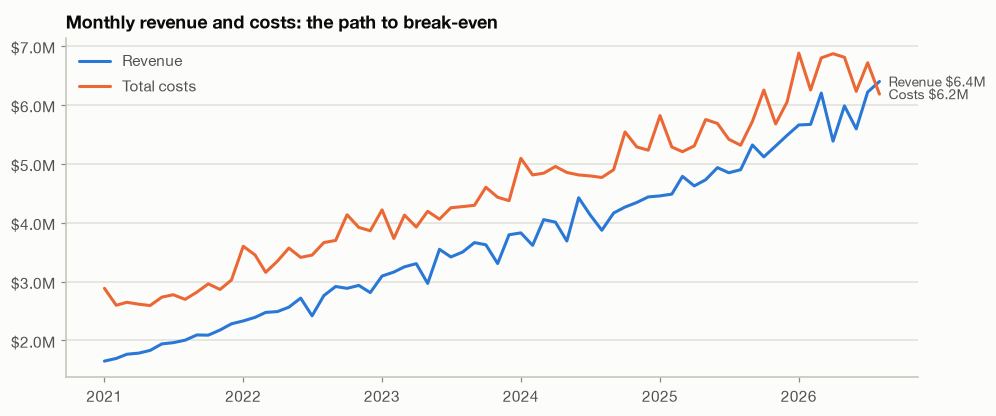

In [7]:
fig, ax = plt.subplots()
ax.plot(monthly.index, monthly["Revenue"], color=ROLE["actual"], label="Revenue")
ax.plot(monthly.index, monthly["Costs"], color=viz.SERIES[1], label="Total costs")
for col in ("Revenue", "Costs"):
    viz.end_label(ax, monthly.index[-1], monthly[col].iloc[-1], f"{col} {usd(monthly[col].iloc[-1])}")
usd_axis(ax)
ax.set_title("Monthly revenue and costs: the path to break-even")
ax.legend(loc="upper left")
plt.show()

**Read-out:** revenue grew from about $1.7M to about $6M a month. Costs grew more slowly as the company went through a hiring freeze (Nov-22 to Mar-23), lost its largest customer (Jul-24) and raised prices (from Jul-25). The operating margin improved from -43% to around break-even.

In [8]:
# Cost mix by function
costs = pnl[pnl["account_type"] != "Revenue"].copy()
costs["year"] = costs["ds"].dt.year
mix = costs.pivot_table(index="year", columns="function", values="actual_usd", aggfunc="sum")
(mix.div(mix.sum(axis=1), axis=0)).map("{:.0%}".format)

function,Cost of Revenue,General & Administrative,Research & Development,Sales & Marketing
year,,,,
2021,21%,22%,30%,26%
2022,22%,21%,29%,29%
2023,22%,20%,30%,29%
2024,22%,20%,29%,29%
2025,22%,19%,29%,30%
2026,23%,20%,28%,29%


## 4. Seasonality: what repeats every year

A robust STL decomposition splits each line into **trend + seasonal pattern + noise**. The seasonal pattern is what a good forecast must reproduce. The noise is what variance analysis has to live with.

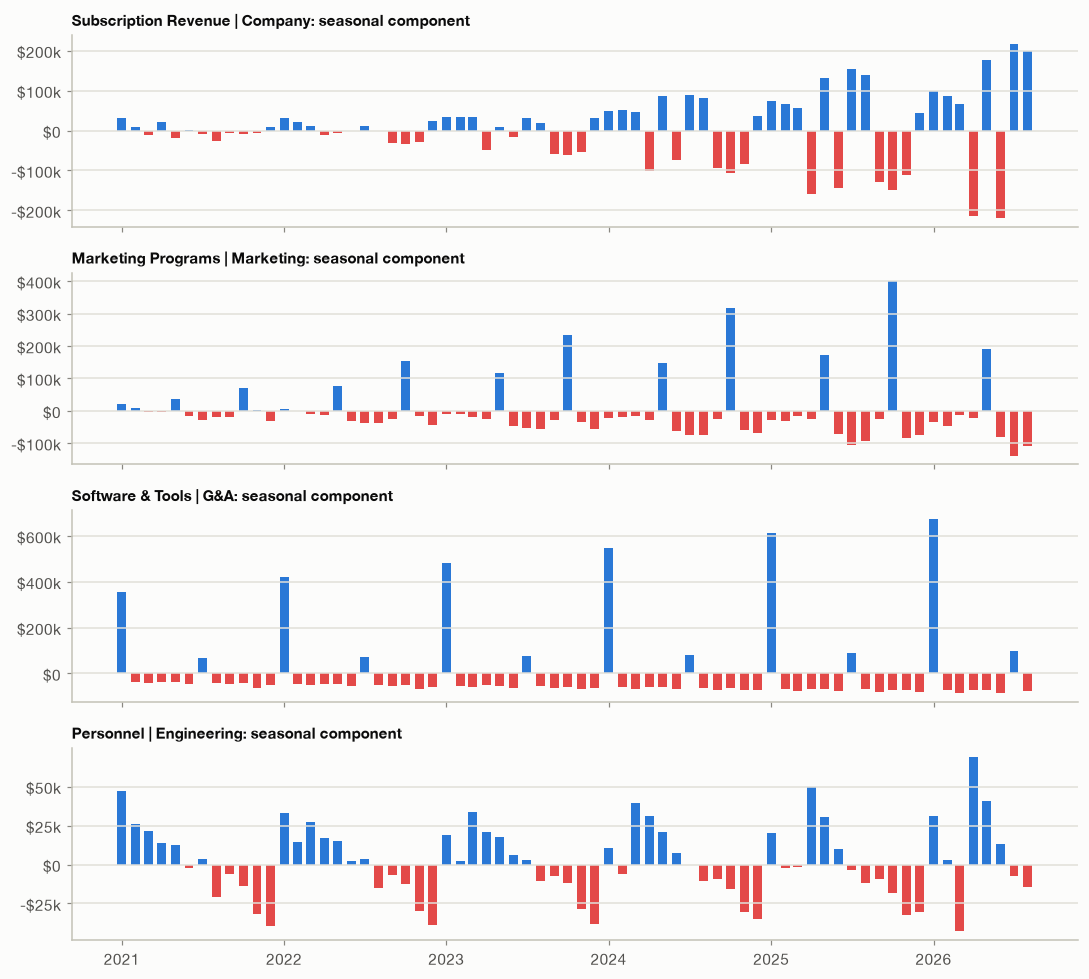

In [9]:
series = pnl.assign(unique_id=pnl["fs_line"] + " | " + pnl["department"]).pivot_table(index="ds", columns="unique_id", values="actual_usd")
examples = ["Subscription Revenue | Company", "Marketing Programs | Marketing", "Software & Tools | G&A", "Personnel | Engineering"]
fig, axes = plt.subplots(len(examples), 1, figsize=(10, 9), sharex=True)
for ax, name in zip(axes, examples):
    s = series[name].fillna(0)
    seasonal = STL(s.to_numpy(), period=12, robust=True).fit().seasonal
    ax.bar(s.index, seasonal, width=20, color=np.where(seasonal >= 0, viz.SERIES[0], viz.SERIES[7]))
    ax.set_title(f"{name}: seasonal component", fontsize=10)
    usd_axis(ax)
fig.tight_layout()
plt.show()

**Read-out:**
- **Subscription revenue** has only mild seasonality (about ±3%). Year-end bookings lift the months that follow, and the remaining wiggles are one-off credit memos. The line is driven by ARR.
- **Marketing** peaks with the May trade show and the October user conference.
- **Software** spikes every January when annual licences renew.
- **Engineering payroll** peaks in Q1 because US payroll taxes are front-loaded until social-security caps are reached, and it steps up each April with merit increases.

## 5. Drivers: what explains the big lines

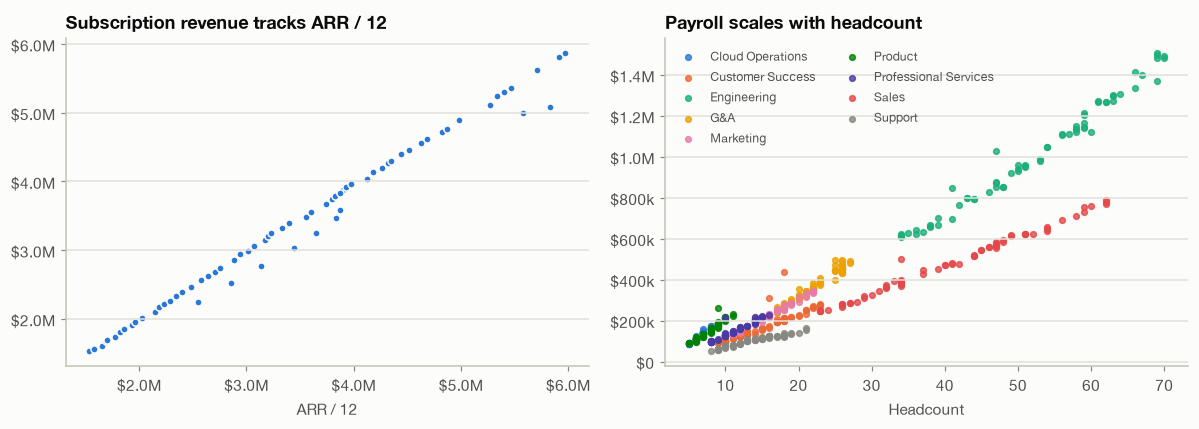

Correlation, ARR/12 vs subscription revenue: 0.994


In [10]:
arr = pd.read_parquet(MARTS / "fct_arr.parquet")
arr["ds"] = pd.PeriodIndex(arr["period"], freq="M").to_timestamp()
hc = pd.read_parquet(MARTS / "fct_headcount.parquet")
hc["ds"] = pd.PeriodIndex(hc["period"], freq="M").to_timestamp()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
rev = series["Subscription Revenue | Company"]
a1.scatter(arr.set_index("ds")["ending_arr"].reindex(rev.index) / 12, rev, s=22, color=viz.SERIES[0], edgecolor=viz.SURFACE, linewidth=1)
a1.set_title("Subscription revenue tracks ARR / 12")
a1.set_xlabel("ARR / 12"); usd_axis(a1); usd_axis(a1, "x")

pers = pnl[pnl["fs_line"] == "Personnel"].merge(hc, on=["ds", "department"])
for i, (dept, g) in enumerate(pers.groupby("department")):
    a2.scatter(g["headcount"], g["actual_usd"], s=14, color=viz.SERIES[i % 8] if i < 8 else viz.MUTED, label=dept, alpha=0.8)
a2.set_title("Payroll scales with headcount")
a2.set_xlabel("Headcount"); usd_axis(a2)
a2.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()
print("Correlation, ARR/12 vs subscription revenue:", round(np.corrcoef(arr.set_index("ds")["ending_arr"].reindex(rev.index), rev)[0, 1], 3))

These relationships motivate two design choices. The **ARR run-rate** driver model competes for subscription revenue, and the **headcount plan** is fed to the machine-learning model as a known future input.

## 6. How good is the annual budget?

The budget (annual operating plan) is locked every November. It assumes a stretch growth target and a hiring plan without recruiting delays, and it knows nothing about customer churn, price changes or one-off events. How far off does it end up?

In [11]:
bud = pd.read_parquet(MARTS / "fct_budget_monthly.parquet")
bud["unique_id"] = bud["fs_line"] + " | " + bud["department"]
act = pnl.assign(unique_id=pnl["fs_line"] + " | " + pnl["department"])
both = act.merge(bud[["unique_id", "period", "budget_usd"]], on=["unique_id", "period"])
both["year"] = both["period"].str[:4]

def wape(g):
    return np.abs(g["actual_usd"] - g["budget_usd"]).sum() / g["actual_usd"].abs().sum()

by_year = both.groupby("year").apply(wape, include_groups=False).rename("Budget error (WAPE)")
by_year.map("{:.1%}".format).to_frame()

,Budget error (WAPE)
year,
2021,11.7%
2022,16.0%
2023,15.2%
2024,11.7%
2025,10.6%
2026,9.4%


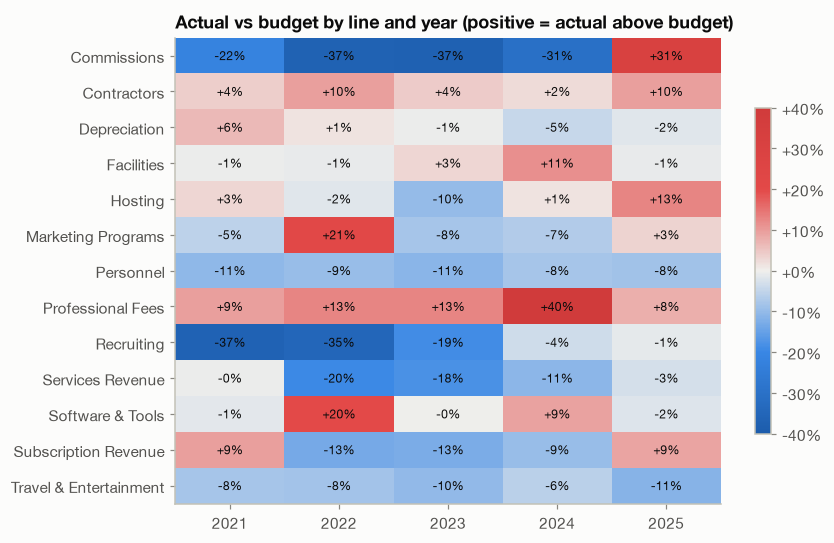

In [12]:
# Full-year actual vs budget by P&L line (% over / under)
full_years = both[both["year"] < meta["as_of"][:4]]
line = full_years.groupby(["fs_line", "year"])[["actual_usd", "budget_usd"]].sum()
gap = (line["actual_usd"] / line["budget_usd"] - 1).unstack()

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(gap.clip(-0.4, 0.4), cmap=viz.DIVERGING.reversed(), vmin=-0.4, vmax=0.4, aspect="auto")
ax.set_xticks(range(gap.shape[1]), gap.columns); ax.set_yticks(range(gap.shape[0]), gap.index)
for (i, j), v in np.ndenumerate(gap.to_numpy()):
    ax.text(j, i, f"{v:+.0%}", ha="center", va="center", fontsize=8, color=viz.INK)
ax.grid(False)
ax.set_title("Actual vs budget by line and year (positive = actual above budget)")
fig.colorbar(im, ax=ax, format=FuncFormatter(lambda v, _: f"{v:+.0%}"), shrink=0.7)
plt.show()

**Read-out:** the budget misses by **10-16% a year** (WAPE across lines and months). Some misses are systematic: payroll under-runs because hires land later than planned, and commissions depend on bookings that are hard to call a year out. Others are shocks the plan could not know about, such as losing the largest customer in 2024 or raising prices in 2025.

A budget is a target, not a forecast. That is the case for a **rolling forecast that re-learns every month**, which [notebook 02](02_forecast_backtesting.ipynb) builds and tests.

### Key takeaways
1. The raw extract needs cleaning (duplicates, missing coding), and every fix is logged and reconciled.
2. Most lines have strong, stable seasonality. A few are lumpy (legal, contractors, recruiting).
3. ARR and headcount explain the two biggest lines.
4. The static budget carries double-digit error, which leaves room for a better forecast.